In [2]:
# Import the packages we will use
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import h5py
import bioframe
from matplotlib.gridspec import GridSpec
from matplotlib.gridspec import GridSpecFromSubplotSpec
import matplotlib.colors as colors
import cooler
import seaborn as sns
from matplotlib.colors import ListedColormap
import os
import bbi
import matplotlib as mpl
import cooltools
import cooler
import re
#from pybedtools import bedtool
#import pybedtools
#from matplotlib_venn import venn2
import itertools

In [3]:
hg38 = bioframe.fetch_chromsizes('hg38')
chromsizes = bioframe.fetch_chromsizes('hg38')
chromosomes = list(chromsizes.index)

In [4]:
# make matplotlib pdf-s text recognizable by evil-Adobe
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['svg.fonttype'] ='path'
matplotlib.rcParams['ps.fonttype'] = 42

In [5]:
cd /home/ozgun.uyan-umw/HiC_analyses_2023/old_cluster_home_folder/plots

/home/ozgun.uyan-umw/HiC_analyses_2023/old_cluster_home_folder/plots


/home/ozgun.uyan-umw/miniconda3/envs/cooltools054/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [6]:
conditions = ['Fib','IPSC2', 'MN-W6']
binsize = 100000
binsize_human = f"{int(binsize/1_000)}kb"

cooler_paths = {    
    'Fib' : f'/home/ozgun.uyan-umw/HiC_analyses_2023/mcools_ALS/OU-HiC-N6-pfib-D4__hg38.hg38.mapq_30.1000.mcool::resolutions/{binsize}',
    'IPSC2' : f'/home/ozgun.uyan-umw/HiC_analyses_2023/mcools_ALS/OU-HiC-N6IPSC2-R1__hg38.hg38.mapq_30.1000.mcool::resolutions/{binsize}',
    'MN-W6' : f'/home/ozgun.uyan-umw/HiC_analyses_2023/mcools_ALS/OU-HiC-N6IPSC2MND45-R2__hg38.hg38.mapq_30.1000.mcool::resolutions/{binsize}',
}
long_names = {
    'Fib' : 'OU-HiC-N6-pfib-D4',
    'IPSC2' : 'OU-HiC-N6IPSC2-R1',
    'MN-W6' : 'OU-HiC-N6IPSC2MND45-R2',

}

pal = sns.color_palette('colorblind')
colors = {
    'Fib' : "#34495e", #dark blue
    'IPSC2' : "#e74c3c", #orange
    'MN-W6' : pal[2], #green

}

clrs = {
    cond: cooler.Cooler(cooler_paths[cond]) for cond in conditions
}

In [7]:
cmap2 = mpl.colors.LinearSegmentedColormap.from_list('mycmap', ['#FFFFFF', '#F5A623', '#D0021B', '#000000'])
#cmap2.set_bad(color='grey') #this works to set NAs as grey, but this data isn't deep enough, doesn't look nice

In [9]:
#if eigens already calculated, can just read in from file
#With eigen1
#Add compartment eigen to heatmap plot
binsize = 100000
eigDFs = {}

for cond in conditions:
    eigDFs[cond] = pd.read_csv(f'/pi/robert.brown-umw/nl/ozgun/Snehal_HDD/cooltools54/EV1_flipped_versions_v2/{long_names[cond]}_100kb_arms.cis.vecs.tsv', sep = "\t")
    
    
    
    

/tmp/ipykernel_3541898/350113967.py:40: RuntimeWarning: divide by zero encountered in log10
  np.log10(cis), extent=[mids[0]/1000000,
/tmp/ipykernel_3541898/350113967.py:40: RuntimeWarning: divide by zero encountered in log10
  np.log10(cis), extent=[mids[0]/1000000,
/tmp/ipykernel_3541898/350113967.py:40: RuntimeWarning: divide by zero encountered in log10
  np.log10(cis), extent=[mids[0]/1000000,


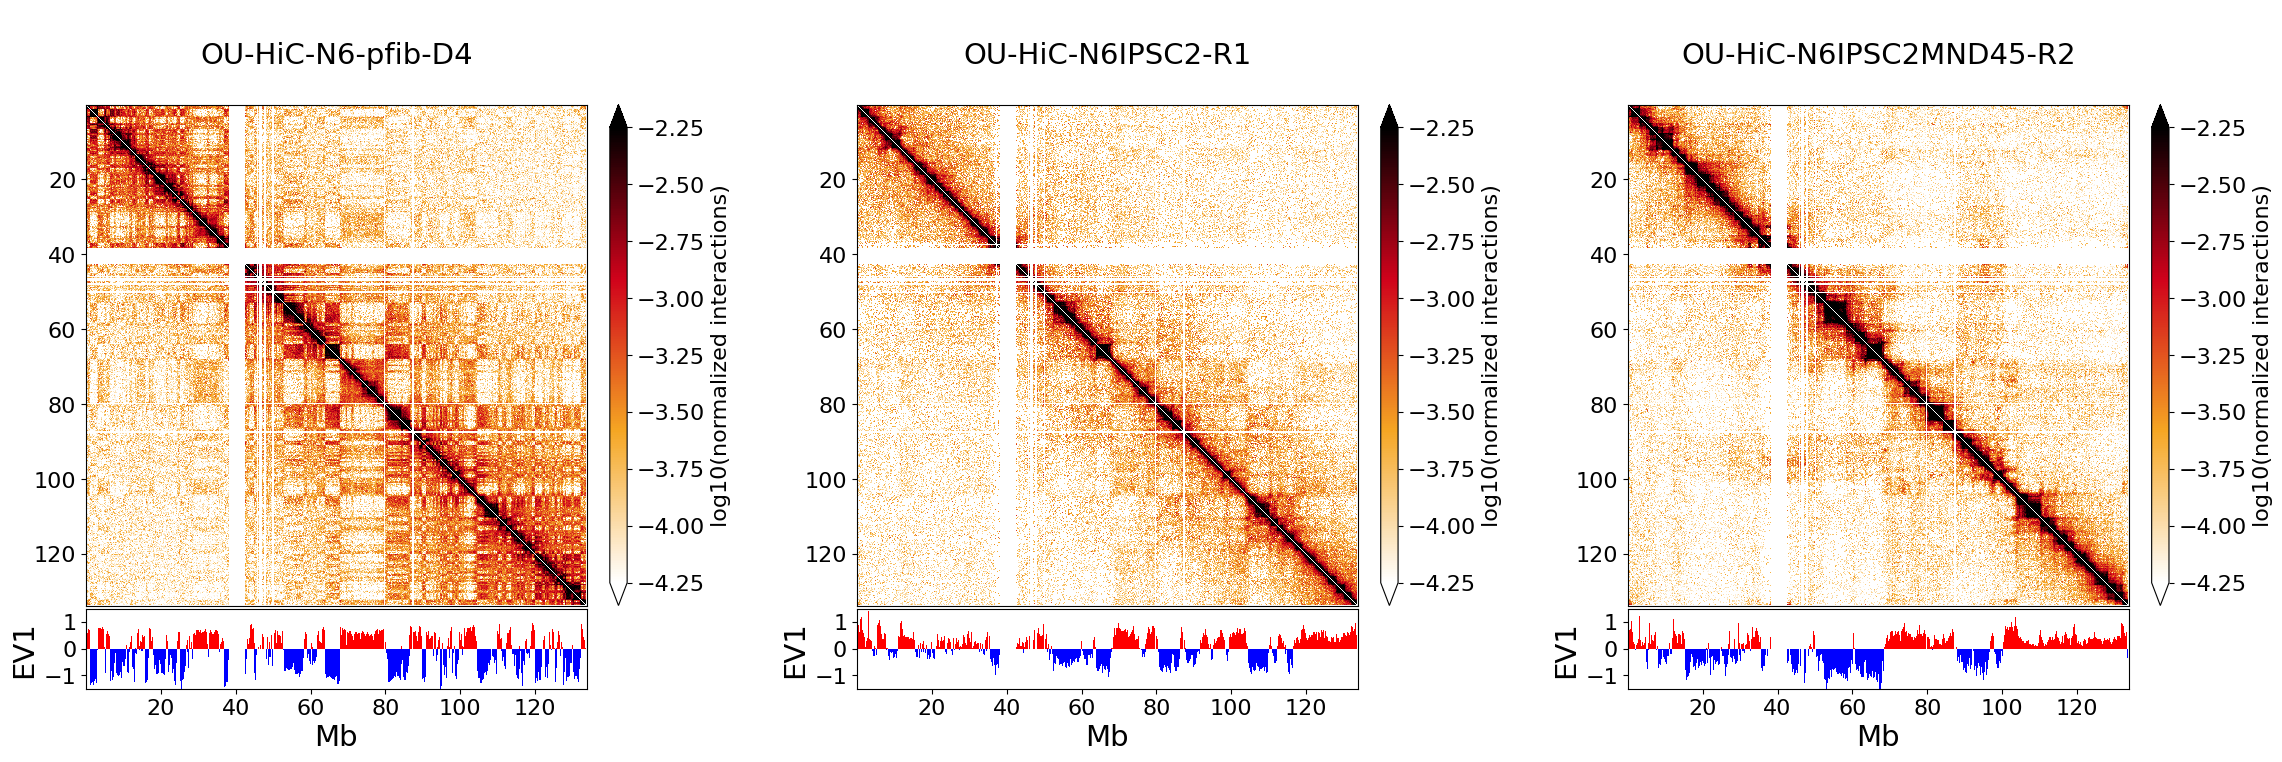

In [10]:
chromosome = "chr10:1-133797422"
chromforev1 = "chr10"
xmin = 1
xmax = 133797422
#chromosome = "chr15"

fig = plt.figure(figsize=(9 * len(conditions), 8))

opts = dict(
    vmin=-4.25, #change scale range here
    vmax=-2.25,
    cmap=cmap2
)

gs0 = GridSpec(nrows=1, ncols=len(conditions), wspace = 0.4)

for i, cond in enumerate(conditions):
    gs1 = GridSpecFromSubplotSpec(nrows = 2, ncols = 2, 
                                  height_ratios=[5, 1], 
                                  width_ratios = [30, 1], 
                                  wspace=.05, hspace = 0.05, subplot_spec = gs0[i])

    c = clrs[cond]
    cis = c.matrix(balance = True).fetch(chromosome)
    
    i,j = np.indices(cis.shape)
    i = i.flatten()
    j = j.flatten()
    # fill NaNs inside of the desired selection:
    nan_band_selector = (np.abs(i-j) < 2) #fills 2 bins on diagonal with nan
    cis[i[nan_band_selector],j[nan_band_selector]] = np.nan
    
    cisbins = c.bins().fetch(chromosome)
    mids = cisbins['end'] - binsize/2
    mids = mids.reset_index(drop=True)
    
    #plot heatmap
    ax = plt.subplot(gs1[0, 0])
    img = ax.matshow( #can change this to plt.imshow instead probably?
        np.log10(cis), extent=[mids[0]/1000000, 
                               mids.iloc[-1]/1000000, 
                               mids.iloc[-1]/1000000, 
                               mids[0]/1000000], 
        **opts)
    ax.xaxis.set_visible(False)
    ax.yaxis.tick_left()    
    plt.title('\n' + long_names[cond] + '\n')
    #plt.ylabel('Mb')
    
    # color bar in it's own axis, and own gridspace
    colorAx = plt.subplot(gs1[0, 1])
    cb = plt.colorbar(img, cax = colorAx, extend = 'both')
    cb.set_label('log10(normalized interactions)')
    ax.set_aspect('equal')
    
    # barplot of eigenvalues
    #make sure lines up with heatmap!
    pos1 = ax.get_position() # get the heatmap position
    pos2 = [pos1.x0, 0.15, pos1.width, .1] #specify xy position, width and height

    ax1 = plt.subplot(gs1[1, 0])
    #set to be same x position as heatmap
    ax1.set_position(pos2) # set a new position
    plt.ylim(-1.5, 1.5)
    plt.xlim(xmin/1000000, xmax /1000000)
    img2 = ax1.bar(
        x = list((eigDFs[cond][eigDFs[cond].chrom == chromforev1]['start'] + binsize/2)/1000000), 
        height = list(eigDFs[cond][eigDFs[cond].chrom == chromforev1]['E1']),
        width = 0.15,
        color=eigDFs[cond].E1[eigDFs[cond].chrom == chromforev1].apply(lambda x: 'r' if x>0 else 'b')
                  )
    plt.ylabel('EV1')
    plt.xlabel('Mb')
    fig.add_subplot(ax1)
    
    #set font sizes
    for item in ([cb.ax.yaxis.label] +
                 ax.get_xticklabels() + 
                 ax.get_yticklabels() +
                 cb.ax.get_yticklabels() +
                 ax1.get_xticklabels() + 
                 ax1.get_yticklabels()):
        item.set_fontsize(16)
        
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label, ax1.title, ax1.xaxis.label, ax1.yaxis.label]):
        item.set_fontsize(21)

plt.savefig("figure_2a_EV1_flipped_2025_width=0.15.svg", format='svg', dpi = 300, bbox_inches = 'tight', pad_inches=0)

/tmp/ipykernel_92426/572194916.py:40: RuntimeWarning: divide by zero encountered in log10
  np.log10(cis), extent=[mids[0]/1000000,
/tmp/ipykernel_92426/572194916.py:40: RuntimeWarning: divide by zero encountered in log10
  np.log10(cis), extent=[mids[0]/1000000,
/tmp/ipykernel_92426/572194916.py:40: RuntimeWarning: divide by zero encountered in log10
  np.log10(cis), extent=[mids[0]/1000000,


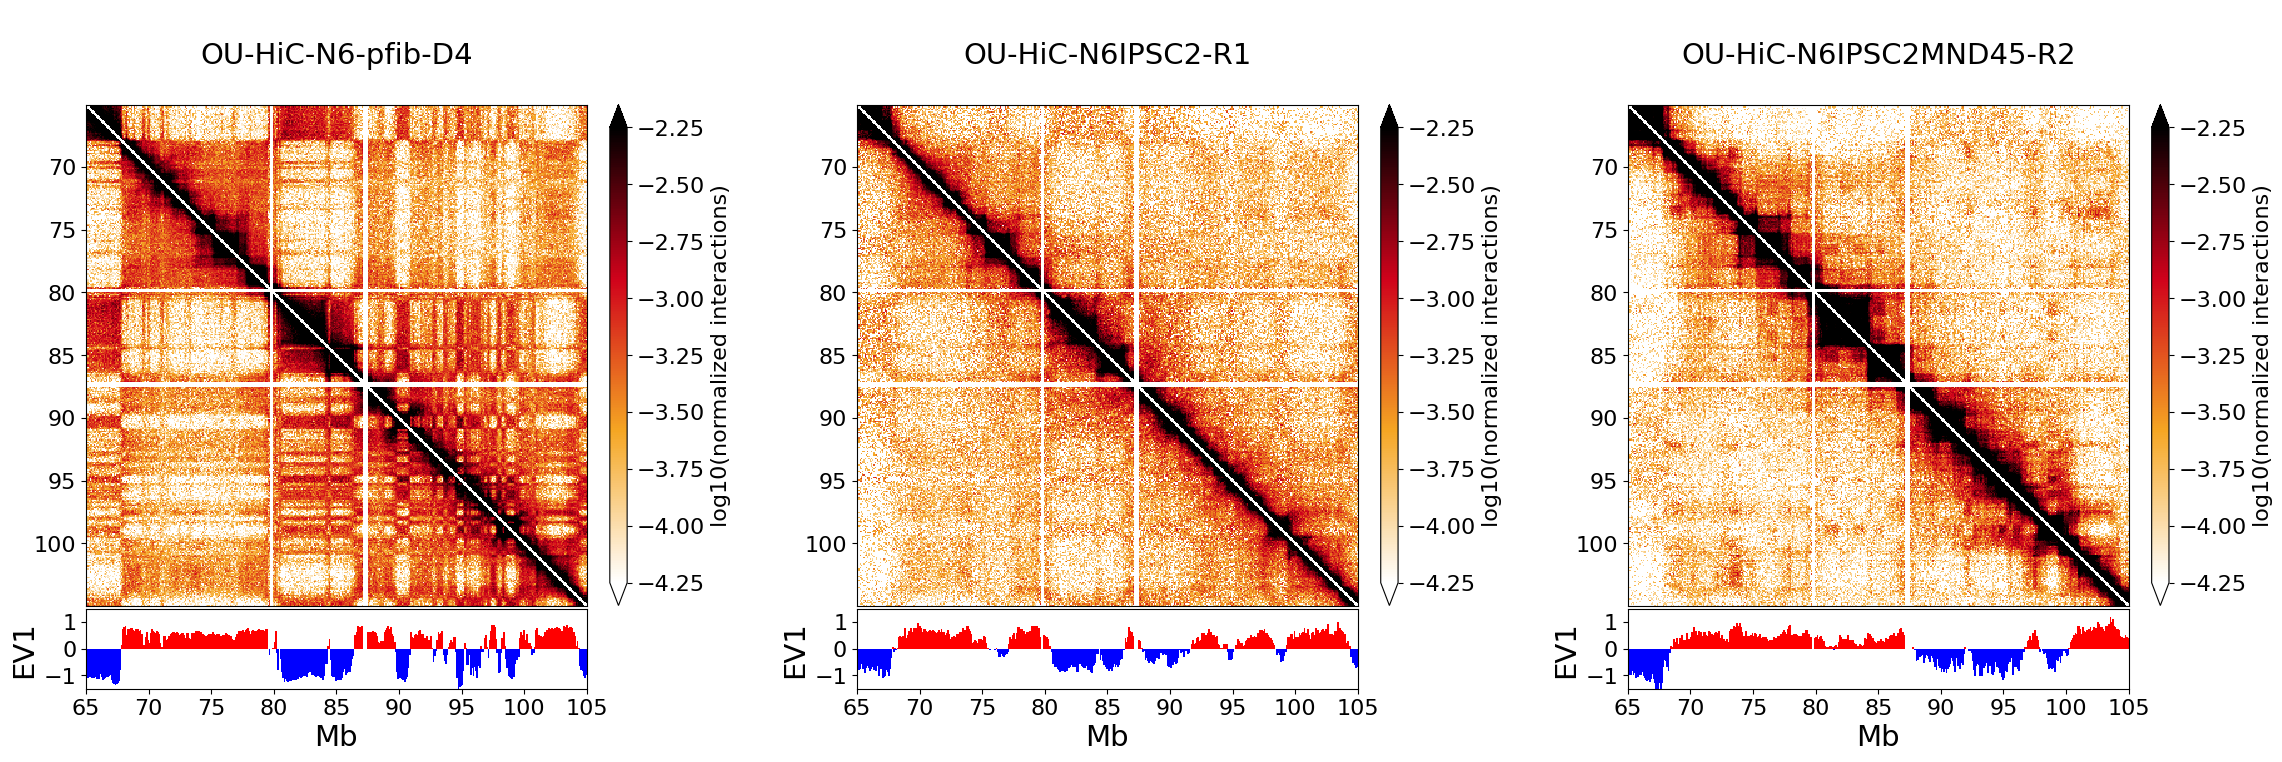

In [ ]:
chromosome = "chr10:65000000-105000000"
chromforev1 = "chr10"
xmin = 65000000
xmax = 105000000
#chromosome = "chr15"

fig = plt.figure(figsize=(9 * len(conditions), 8))

opts = dict(
    vmin=-4.25, #change scale range here
    vmax=-2.25,
    cmap=cmap2
)

gs0 = GridSpec(nrows=1, ncols=len(conditions), wspace = 0.4)

for i, cond in enumerate(conditions):
    gs1 = GridSpecFromSubplotSpec(nrows = 2, ncols = 2, 
                                  height_ratios=[5, 1], 
                                  width_ratios = [30, 1], 
                                  wspace=.05, hspace = 0.05, subplot_spec = gs0[i])

    c = clrs[cond]
    cis = c.matrix(balance = True).fetch(chromosome)
    
    i,j = np.indices(cis.shape)
    i = i.flatten()
    j = j.flatten()
    # fill NaNs inside of the desired selection:
    nan_band_selector = (np.abs(i-j) < 2) #fills 2 bins on diagonal with nan
    cis[i[nan_band_selector],j[nan_band_selector]] = np.nan
    
    cisbins = c.bins().fetch(chromosome)
    mids = cisbins['end'] - binsize/2
    mids = mids.reset_index(drop=True)
    
    #plot heatmap
    ax = plt.subplot(gs1[0, 0])
    img = ax.matshow( #can change this to plt.imshow instead probably?
        np.log10(cis), extent=[mids[0]/1000000, 
                               mids.iloc[-1]/1000000, 
                               mids.iloc[-1]/1000000, 
                               mids[0]/1000000], 
        **opts)
    ax.xaxis.set_visible(False)
    ax.yaxis.tick_left()    
    plt.title('\n' + long_names[cond] + '\n')
    #plt.ylabel('Mb')
    
    # color bar in it's own axis, and own gridspace
    colorAx = plt.subplot(gs1[0, 1])
    cb = plt.colorbar(img, cax = colorAx, extend = 'both')
    cb.set_label('log10(normalized interactions)')
    ax.set_aspect('equal')
    
    # barplot of eigenvalues
    #make sure lines up with heatmap!
    pos1 = ax.get_position() # get the heatmap position
    pos2 = [pos1.x0, 0.15, pos1.width, .1] #specify xy position, width and height

    ax1 = plt.subplot(gs1[1, 0])
    #set to be same x position as heatmap
    ax1.set_position(pos2) # set a new position
    plt.ylim(-1.5, 1.5)
    plt.xlim(xmin/1000000, xmax /1000000)
    img2 = ax1.bar(
        x = list((eigDFs[cond][eigDFs[cond].chrom == chromforev1]['start'] + binsize/2)/1000000), 
        height = list(eigDFs[cond][eigDFs[cond].chrom == chromforev1]['E1']),
        width = 0.15,
        color=eigDFs[cond].E1[eigDFs[cond].chrom == chromforev1].apply(lambda x: 'r' if x>0 else 'b')
                  )
    plt.ylabel('EV1')
    plt.xlabel('Mb')
    fig.add_subplot(ax1)
    
    #set font sizes
    for item in ([cb.ax.yaxis.label] +
                 ax.get_xticklabels() + 
                 ax.get_yticklabels() +
                 cb.ax.get_yticklabels() +
                 ax1.get_xticklabels() + 
                 ax1.get_yticklabels()):
        item.set_fontsize(16)
        
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label, ax1.title, ax1.xaxis.label, ax1.yaxis.label]):
        item.set_fontsize(21)

plt.savefig("figure_2b_Fib-IPSC-MN-N6-IPSC2-chr10_65-105mb_100kb_binsize_comp_100kb-withEV1.svg", dpi = 300, bbox_inches = 'tight', pad_inches=0)

In [ ]:
chromosome = "chr10:65000000-105000000"
chromforev1 = "chr10"
xmin = 65000000
xmax = 105000000
#chromosome = "chr15"

fig = plt.figure(figsize=(9 * len(conditions), 8))

opts = dict(
    vmin=-4, #change scale range here
    vmax=-2,
    cmap=cmap2
)

gs0 = GridSpec(nrows=1, ncols=len(conditions), wspace = 0.4)

for i, cond in enumerate(conditions):
    gs1 = GridSpecFromSubplotSpec(nrows = 2, ncols = 2, 
                                  height_ratios=[5, 1], 
                                  width_ratios = [30, 1], 
                                  wspace=.05, hspace = 0.05, subplot_spec = gs0[i])

    c = clrs[cond]
    cis = c.matrix(balance = True).fetch(chromosome)
    
    i,j = np.indices(cis.shape)
    i = i.flatten()
    j = j.flatten()
    # fill NaNs inside of the desired selection:
    nan_band_selector = (np.abs(i-j) < 2) #fills 2 bins on diagonal with nan
    cis[i[nan_band_selector],j[nan_band_selector]] = np.nan
    
    cisbins = c.bins().fetch(chromosome)
    mids = cisbins['end'] - binsize/2
    mids = mids.reset_index(drop=True)
    
    #plot heatmap
    ax = plt.subplot(gs1[0, 0])
    img = ax.matshow( #can change this to plt.imshow instead probably?
        np.log10(cis), extent=[mids[0]/1000000, 
                               mids.iloc[-1]/1000000, 
                               mids.iloc[-1]/1000000, 
                               mids[0]/1000000], 
        **opts)
    ax.xaxis.set_visible(False)
    ax.yaxis.tick_left()    
    plt.title('\n' + long_names[cond] + '\n')
    #plt.ylabel('Mb')
    
    # color bar in it's own axis, and own gridspace
    colorAx = plt.subplot(gs1[0, 1])
    cb = plt.colorbar(img, cax = colorAx, extend = 'both')
    cb.set_label('log10(normalized interactions)')
    ax.set_aspect('equal')
    
    # barplot of eigenvalues
    #make sure lines up with heatmap!
    pos1 = ax.get_position() # get the heatmap position
    pos2 = [pos1.x0, 0.15, pos1.width, .1] #specify xy position, width and height

    ax1 = plt.subplot(gs1[1, 0])
    #set to be same x position as heatmap
    ax1.set_position(pos2) # set a new position
    plt.ylim(-1.5, 1.5)
    plt.xlim(xmin/1000000, xmax /1000000)
    img2 = ax1.bar(
        x = list((eigDFs[cond][eigDFs[cond].chrom == chromforev1]['start'] + binsize/2)/1000000), 
        height = list(eigDFs[cond][eigDFs[cond].chrom == chromforev1]['E1']),
        width = 0.15,
        color=eigDFs[cond].E1[eigDFs[cond].chrom == chromforev1].apply(lambda x: 'r' if x>0 else 'b')
                  )
    plt.ylabel('EV1')
    plt.xlabel('Mb')
    fig.add_subplot(ax1)
    
    #set font sizes
    for item in ([cb.ax.yaxis.label] +
                 ax.get_xticklabels() + 
                 ax.get_yticklabels() +
                 cb.ax.get_yticklabels() +
                 ax1.get_xticklabels() + 
                 ax1.get_yticklabels()):
        item.set_fontsize(16)
        
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label, ax1.title, ax1.xaxis.label, ax1.yaxis.label]):
        item.set_fontsize(21)

plt.savefig("figure_2b_light_Fib-IPSC-MN-N6-IPSC2-chr10_65-105mb_100kb_binsize_comp_100kb-withEV1.svg", dpi = 300, bbox_inches = 'tight', pad_inches=0)

/tmp/ipykernel_92426/567513566.py:40: RuntimeWarning: divide by zero encountered in log10
  np.log10(cis), extent=[mids[0]/1000000,
/tmp/ipykernel_92426/567513566.py:40: RuntimeWarning: divide by zero encountered in log10
  np.log10(cis), extent=[mids[0]/1000000,
/tmp/ipykernel_92426/567513566.py:40: RuntimeWarning: divide by zero encountered in log10
  np.log10(cis), extent=[mids[0]/1000000,


/tmp/ipykernel_4132287/450714363.py:40: RuntimeWarning: divide by zero encountered in log10
  np.log10(cis), extent=[mids[0]/1000000,
/tmp/ipykernel_4132287/450714363.py:40: RuntimeWarning: divide by zero encountered in log10
  np.log10(cis), extent=[mids[0]/1000000,
/tmp/ipykernel_4132287/450714363.py:40: RuntimeWarning: divide by zero encountered in log10
  np.log10(cis), extent=[mids[0]/1000000,


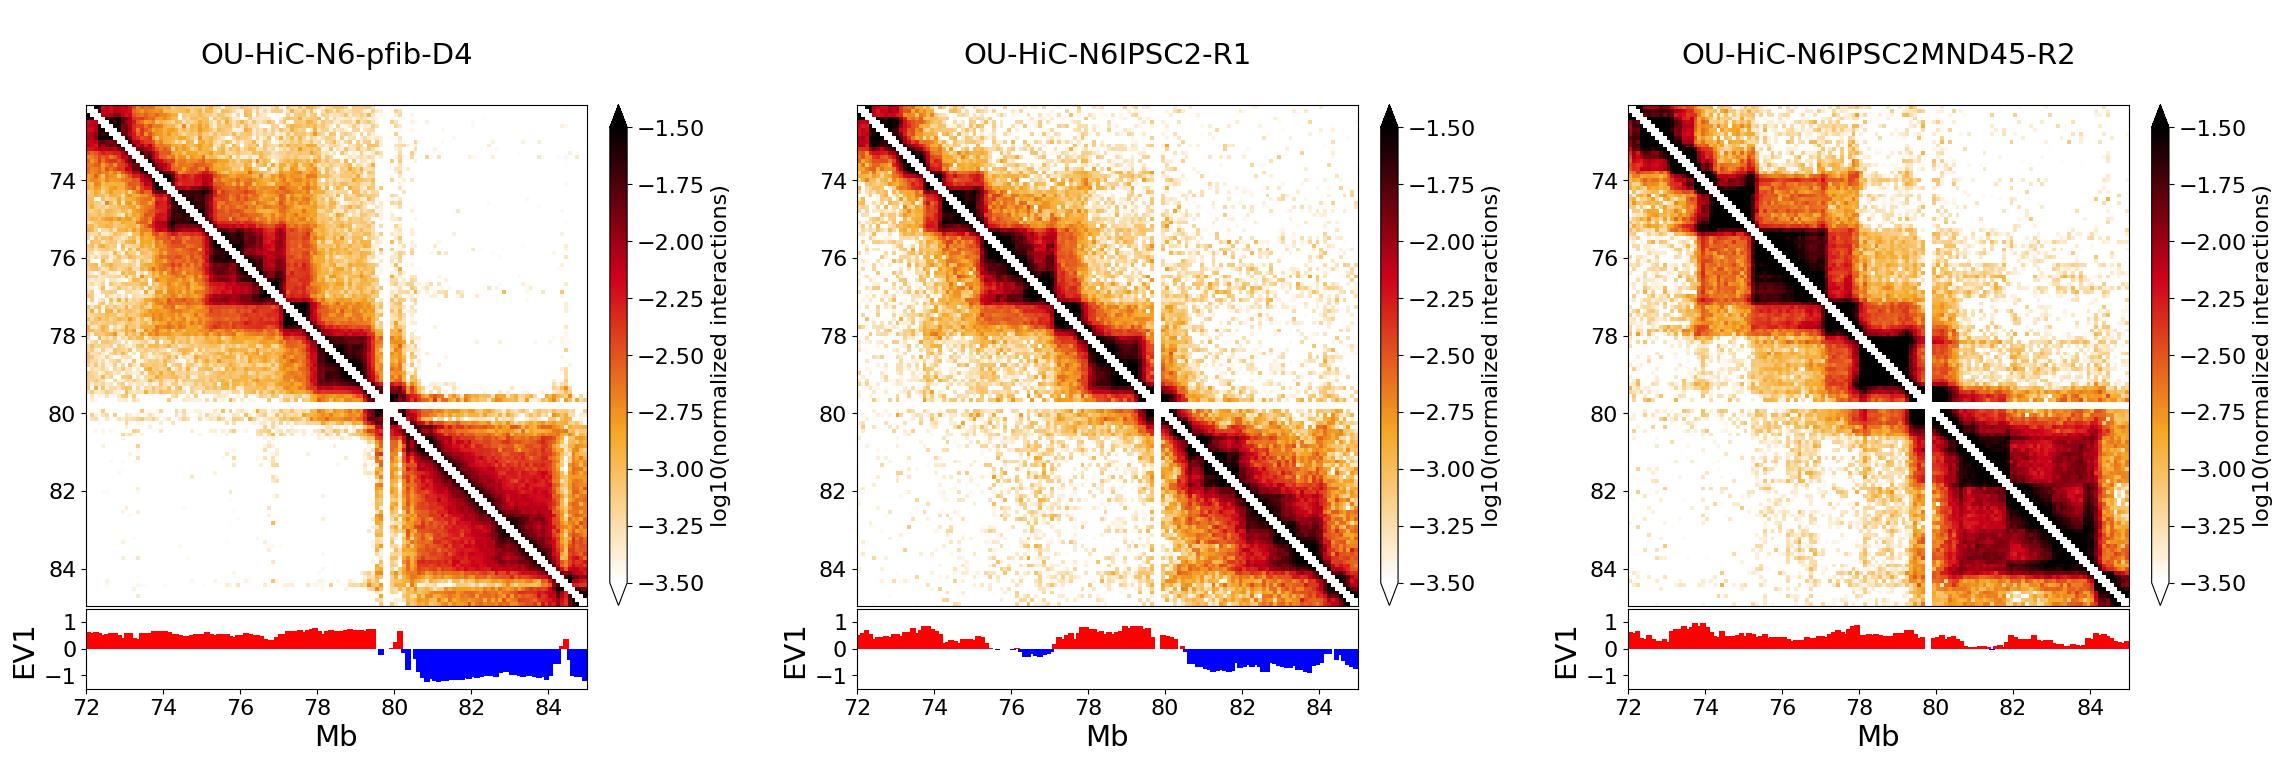

In [ ]:
chromosome = "chr10:72000000-85000000"
chromforev1 = "chr10"
xmin = 72000000
xmax = 85000000
#chromosome = "chr15"

fig = plt.figure(figsize=(9 * len(conditions), 8))

opts = dict(
    vmin=-3.5, #change scale range here
    vmax=-1.5,
    cmap=cmap2
)

gs0 = GridSpec(nrows=1, ncols=len(conditions), wspace = 0.4)

for i, cond in enumerate(conditions):
    gs1 = GridSpecFromSubplotSpec(nrows = 2, ncols = 2, 
                                  height_ratios=[5, 1], 
                                  width_ratios = [30, 1], 
                                  wspace=.05, hspace = 0.05, subplot_spec = gs0[i])

    c = clrs[cond]
    cis = c.matrix(balance = True).fetch(chromosome)
    
    i,j = np.indices(cis.shape)
    i = i.flatten()
    j = j.flatten()
    # fill NaNs inside of the desired selection:
    nan_band_selector = (np.abs(i-j) < 2) #fills 2 bins on diagonal with nan
    cis[i[nan_band_selector],j[nan_band_selector]] = np.nan
    
    cisbins = c.bins().fetch(chromosome)
    mids = cisbins['end'] - binsize/2
    mids = mids.reset_index(drop=True)
    
    #plot heatmap
    ax = plt.subplot(gs1[0, 0])
    img = ax.matshow( #can change this to plt.imshow instead probably?
        np.log10(cis), extent=[mids[0]/1000000, 
                               mids.iloc[-1]/1000000, 
                               mids.iloc[-1]/1000000, 
                               mids[0]/1000000], 
        **opts)
    ax.xaxis.set_visible(False)
    ax.yaxis.tick_left()    
    plt.title('\n' + long_names[cond] + '\n')
    #plt.ylabel('Mb')
    
    # color bar in it's own axis, and own gridspace
    colorAx = plt.subplot(gs1[0, 1])
    cb = plt.colorbar(img, cax = colorAx, extend = 'both')
    cb.set_label('log10(normalized interactions)')
    ax.set_aspect('equal')
    
    # barplot of eigenvalues
    #make sure lines up with heatmap!
    pos1 = ax.get_position() # get the heatmap position
    pos2 = [pos1.x0, 0.15, pos1.width, .1] #specify xy position, width and height

    ax1 = plt.subplot(gs1[1, 0])
    #set to be same x position as heatmap
    ax1.set_position(pos2) # set a new position
    plt.ylim(-1.5, 1.5)
    plt.xlim(xmin/1000000, xmax /1000000)
    img2 = ax1.bar(
        x = list((eigDFs[cond][eigDFs[cond].chrom == chromforev1]['start'] + binsize/2)/1000000), 
        height = list(eigDFs[cond][eigDFs[cond].chrom == chromforev1]['E1']),
        width = 0.15,
        color=eigDFs[cond].E1[eigDFs[cond].chrom == chromforev1].apply(lambda x: 'r' if x>0 else 'b')
                  )
    plt.ylabel('EV1')
    plt.xlabel('Mb')
    fig.add_subplot(ax1)
    
    #set font sizes
    for item in ([cb.ax.yaxis.label] +
                 ax.get_xticklabels() + 
                 ax.get_yticklabels() +
                 cb.ax.get_yticklabels() +
                 ax1.get_xticklabels() + 
                 ax1.get_yticklabels()):
        item.set_fontsize(16)
        
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label, ax1.title, ax1.xaxis.label, ax1.yaxis.label]):
        item.set_fontsize(21)

plt.savefig("figure_2c_lighter_Fib-IPSC-MN-N6-IPSC2-chr10_72-85mb_100kb_binsize_comp_25kb-withEV1.svg", dpi = 300, bbox_inches = 'tight', pad_inches=0)